# 1. IMPOTAÇÃO DAS BIBLIOTECAS

In [53]:

"""
BIBLIOTECAS:
pandas / numpy:
- manipulação dos dados

matplotlib / seaborn:
- visualizações

scikit-learn:
- Machine Learning
- pré-processamento
- métricas
- pipeline
- validação

shap:
- interpretabilidade moderna (XAI)

os: 
  - Gerenciamento de pastas de resultados (_all, _binary, _grouped)
  
pickle: 
  - Exportação da Pipeline (transformer + model)
"""

"""
==================================================
IMPORTAÇÃO DAS BIBLIOTECAS
==================================================

BIBLIOTECAS:

pandas / numpy:
- manipulação dos dados

matplotlib / seaborn:
- visualizações

scikit-learn:
- Machine Learning
- pré-processamento
- métricas
- pipeline
- validação

shap:
- interpretabilidade moderna (XAI)

joblib:
- cache da Pipeline
- acelera transformações repetidas

os:
- gerenciamento de diretórios

pickle:
- exportação da Pipeline final
"""

import warnings
warnings.filterwarnings("ignore")


# SISTEMA
import os
import pickle


# CACHE
from joblib import Memory

# diretório de cache
cachedir = "./cache_dir"

memory = Memory(

    location=cachedir,

    verbose=0
)

# DADOS
import pandas as pd
import numpy as np


# VISUALIZAÇÃO
import matplotlib.pyplot as plt
import seaborn as sns


# PIPELINE
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# PRÉ-PROCESSAMENTO
from sklearn.preprocessing import (

    OneHotEncoder,

    StandardScaler,

    MaxAbsScaler,

    label_binarize
)

# IMPUTAÇÃO
from sklearn.impute import SimpleImputer


# MODELO
from sklearn.linear_model import LogisticRegression


# FEATURE SELECTION
from sklearn.feature_selection import (

    SelectKBest,

    mutual_info_classif,

    VarianceThreshold
)


# GRID SEARCH
from sklearn.model_selection import (

    StratifiedKFold,

    GridSearchCV
)


# BALANCEAMENTO
from sklearn.utils.class_weight import (
    compute_sample_weight
)


# MÉTRICAS
from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix,

    f1_score,

    roc_auc_score,

    top_k_accuracy_score
)


# PCA / TSNE
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# SHAP
import shap


# UTILITÁRIOS
from sklearn.utils.validation import (
    check_is_fitted
)

# VIF
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

# CONFIGURAÇÃO VISUAL
sns.set_style("whitegrid")

pd.set_option(
    "display.max_columns",
    None
)

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


# 2. CARREGAMENTO DOS DADOS

In [54]:
df_train = pd.read_parquet(
    "datasense_full_train_1sec.parquet"
)

df_test = pd.read_parquet(
    "datasense_full_test_1sec.parquet"
)

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)

Train shape: (170393, 115)
Test shape : (56798, 115)


# 3. DEFINIÇÃO DO TARGET

In [55]:
"""
Defini o problema multiclasse.

TARGET:
label4

label4:
- contém os cenários completos de ataques
- representa 84 classes distintas

"""

experimentos = [

    {
        "suffix": "all",
        "target": "label4"
    },

    {
        "suffix": "binary",
        "target": "label1"
    },

    {
        "suffix": "grouped",
        "target": "label2"
    }
]

target_col = "label4"

y_train = df_train[target_col]

y_test = df_test[target_col]

print("Quantidade de classes:")
print(y_train.nunique())

print("\nDistribuição das classes:")
display(y_train.value_counts().head(20))

Quantidade de classes:
84

Distribuição das classes:


label4
benign                             102600
mitm_arp-spoofing                    3148
malware_mirai-udp-flood              3006
recon_os-scan                        2969
recon_vuln-scan                      2956
recon_host-disc-tcp-ack-ping         2952
recon_host-disc-tcp-syn-ping         2945
recon_port-scan                      2939
recon_host-disc-tcp-syn-stealth      2933
recon_host-disc-arp-ping             2927
recon_host-disc-udp-ping             2919
malware_mirai-syn-flood              2647
mitm_ip-spoofing                     2280
recon_ping-sweep                     1663
dos_udp-flood                        1292
dos_icmp-flood                       1289
dos_icmp-frag-flood                  1202
ddos_icmp-flood                      1199
ddos_icmp-frag-flood                 1197
ddos_udp-frag-flood                  1197
Name: count, dtype: int64

# 4. REMOÇÃO DE COLUNAS

In [56]:
"""
Remove apenas labels auxiliares.
"""

label_extended_train = df_train["label_extended"]
label_extended_test = df_test["label_extended"]

cols_to_drop = [

    "label1",
    "label2",
    "label3",
    "label4",
    "label_extended"
]

X_train = df_train.drop(columns=cols_to_drop)

X_test = df_test.drop(columns=cols_to_drop)

print("Quantidade de features:")
print(X_train.shape[1])

Quantidade de features:
110


# 5. IDENTIFICAÇÃO DAS FEATURES

In [57]:
"""
OBJETIVO:
Separar automaticamente as colunas em:

- numéricas
- booleanas
- categóricas

"""

# NUMÉRICAS
numerical_features = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()

# BOOLEANAS
bool_features = X_train.select_dtypes(
    include=["bool"]
).columns.tolist()

# REMOVE BOOLEANAS DAS NUMÉRICAS
numerical_features = [

    col

    for col in numerical_features

    if col not in bool_features
]

# CATEGÓRICAS
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("==================================================")
print("IDENTIFICAÇÃO DAS FEATURES FINALIZADA")
print("==================================================")

print("Numéricas:", len(numerical_features))
print("Booleanas:", len(bool_features))
print("Categóricas:", len(categorical_features))

IDENTIFICAÇÃO DAS FEATURES FINALIZADA
Numéricas: 64
Booleanas: 44
Categóricas: 0


In [58]:
"""
==================================================
VIF — MULTICOLINEARIDADE
==================================================

OBJETIVO:
Avaliar multicolinearidade entre variáveis numéricas
utilizando VIF (Variance Inflation Factor).

INTERPRETAÇÃO:

VIF < 5
- baixo risco

VIF entre 5 e 10
- atenção

VIF > 10
- forte multicolinearidade

OTIMIZAÇÕES:
- amostragem
- limpeza de NaN/Inf
- processamento mais rápido
"""

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

# ==================================================
# CONFIGURAÇÕES
# ==================================================

sample_size = 5000

# ==================================================
# DADOS NUMÉRICOS
# ==================================================

X_vif = X_train[
    numerical_features
].copy()

# ==================================================
# LIMPEZA
# ==================================================

X_vif = X_vif.replace(

    [np.inf, -np.inf],

    np.nan
)

X_vif = X_vif.fillna(

    X_vif.median(numeric_only=True)
)

# ==================================================
# AMOSTRAGEM
# ==================================================

if len(X_vif) > sample_size:

    X_vif_sample = X_vif.sample(

        n=sample_size,

        random_state=42
    )

else:

    X_vif_sample = X_vif.copy()

print("==================================================")
print("CÁLCULO DE VIF")
print("==================================================")

print("\nShape da amostra:")
print(X_vif_sample.shape)

# ==================================================
# CÁLCULO DO VIF
# ==================================================

vif_data = pd.DataFrame()

vif_data["Feature"] = (
    X_vif_sample.columns
)

vif_data["VIF"] = [

    variance_inflation_factor(

        X_vif_sample.values,

        i
    )

    for i in range(
        X_vif_sample.shape[1]
    )
]

# ==================================================
# ORDENAÇÃO
# ==================================================

vif_data = vif_data.sort_values(

    by="VIF",

    ascending=False
).reset_index(drop=True)

# ==================================================
# CLASSIFICAÇÃO AUTOMÁTICA
# ==================================================

vif_data["Status"] = np.where(

    vif_data["VIF"] > 10,

    "ALTO",

    np.where(
        vif_data["VIF"] > 5,
        "MODERADO",
        "BAIXO"
    )
)

# ==================================================
# RESULTADOS
# ==================================================

print("\nTop 20 maiores VIFs:")

display(
    vif_data.head(20)
)

print("\nQuantidade com VIF > 10:")
print(
    (vif_data["VIF"] > 10).sum()
)

print("\nQuantidade com VIF > 5:")
print(
    (vif_data["VIF"] > 5).sum()
)

CÁLCULO DE VIF

Shape da amostra:
(5000, 64)

Top 20 maiores VIFs:


,Feature,VIF,Status
0,network_packets_all_count,inf,ALTO
1,network_packets_dst_count,inf,ALTO
2,network_header-length_avg,inf,ALTO
3,network_header-length_max,inf,ALTO
4,network_header-length_min,inf,ALTO
5,network_packets_src_count,inf,ALTO
6,network_macs_src_count,inf,ALTO
7,network_macs_dst_count,inf,ALTO
8,network_mss_max,1.825749e+04,ALTO
9,network_mss_avg,1.501953e+04,ALTO



Quantidade com VIF > 10:
57

Quantidade com VIF > 5:
59


In [59]:
"""
==================================================
REMOÇÃO AUTOMÁTICA DE FEATURES COM VIF ALTO
==================================================

OBJETIVO:
Remover features com alta multicolinearidade.

BENEFÍCIOS:
- melhora estabilidade da regressão
- reduz redundância
- reduz overfitting
- melhora interpretabilidade

OTIMIZAÇÕES:
- usa amostra
- limita iterações
- processamento mais rápido
"""

# ==================================================
# CONFIGURAÇÕES
# ==================================================

VIF_THRESHOLD = 10

MAX_ITERATIONS = 10

SAMPLE_SIZE = 10000

# ==================================================
# AMOSTRAGEM
# ==================================================

X_vif_reduce = X_train[
    numerical_features
].sample(

    n=SAMPLE_SIZE,

    random_state=42
).copy()

# ==================================================
# LIMPEZA
# ==================================================

X_vif_reduce = X_vif_reduce.replace(
    [np.inf, -np.inf],
    np.nan
)

X_vif_reduce = X_vif_reduce.fillna(
    X_vif_reduce.median(numeric_only=True)
)

# ==================================================
# FEATURES INICIAIS
# ==================================================

remaining_features = (
    X_vif_reduce.columns.tolist()
)

removed_features = []

print("==================================================")
print("INICIANDO REMOÇÃO VIF")
print("==================================================")

print(f"\nFeatures iniciais: {len(remaining_features)}")

# ==================================================
# LOOP DE REMOÇÃO
# ==================================================

for iteration in range(MAX_ITERATIONS):

    print(f"\nIteração {iteration + 1}")

    vif = pd.DataFrame()

    vif["Feature"] = remaining_features

    vif["VIF"] = [

        variance_inflation_factor(

            X_vif_reduce[
                remaining_features
            ].values,

            i
        )

        for i in range(
            len(remaining_features)
        )
    ]

    max_vif = vif["VIF"].max()

    print(f"Maior VIF encontrado: {max_vif:.2f}")

    # ==================================================
    # PARADA
    # ==================================================

    if max_vif < VIF_THRESHOLD:

        print("\nTodos os VIFs aceitáveis.")
        break

    # ==================================================
    # REMOVE FEATURES COM VIF ALTO
    # ==================================================

    high_vif_features = vif[
        vif["VIF"] > VIF_THRESHOLD
    ]["Feature"].tolist()

    print(
        f"Removendo {len(high_vif_features)} features..."
    )

    for feature in high_vif_features:

        if feature in remaining_features:

            remaining_features.remove(feature)

            removed_features.append(feature)

    print(
        f"Features restantes: {len(remaining_features)}"
    )

# ==================================================
# RESULTADO FINAL
# ==================================================

numerical_features_vif = remaining_features

print("\n==================================================")
print("REMOÇÃO VIF FINALIZADA")
print("==================================================")

print("\nQuantidade final de features:")
print(len(numerical_features_vif))

print("\nQuantidade removida:")
print(len(removed_features))

print("\nExemplo de removidas:")
print(removed_features[:20])

INICIANDO REMOÇÃO VIF

Features iniciais: 64

Iteração 1
Maior VIF encontrado: inf
Removendo 57 features...
Features restantes: 7

Iteração 2
Maior VIF encontrado: 1.78

Todos os VIFs aceitáveis.

REMOÇÃO VIF FINALIZADA

Quantidade final de features:
7

Quantidade removida:
57

Exemplo de removidas:
['network_fragmentation-score', 'network_fragmented-packets', 'network_header-length_avg', 'network_header-length_max', 'network_header-length_min', 'network_ip-flags_avg', 'network_ip-flags_max', 'network_ip-flags_std_deviation', 'network_ip-length_avg', 'network_ip-length_max', 'network_ip-length_min', 'network_ip-length_std_deviation', 'network_ips_all_count', 'network_ips_dst_count', 'network_ips_src_count', 'network_macs_all_count', 'network_macs_dst_count', 'network_macs_src_count', 'network_mss_avg', 'network_mss_max']


#6. PIPELINE DE PRÉ-PROCESSAMENTO

In [60]:
"""
==================================================
PIPELINE DE PRÉ-PROCESSAMENTO
==================================================

OBJETIVO:
Aplicar transformações específicas para:

- numéricas
- booleanas
- categóricas

"""

# TRANSFORMA BOOLEANAS EM INT
X_train[bool_features] = (
    X_train[bool_features]
    .astype(int)
)

X_test[bool_features] = (
    X_test[bool_features]
    .astype(int)
)


# PIPELINE NUMÉRICA
numeric_transformer = Pipeline([

    (
        "imputer",

        SimpleImputer(strategy="median")
    ),

    (
        "scaler",

        StandardScaler()
    )

], memory=memory)

# PIPELINE BOOLEANA
bool_transformer = Pipeline([

    (
        "imputer",

        SimpleImputer(strategy="most_frequent")
    )

], memory=memory)


# PIPELINE CATEGÓRICA
categorical_transformer = Pipeline([

    (
        "imputer",

        SimpleImputer(strategy="most_frequent")
    ),

    (
        "onehot",

        OneHotEncoder(

            handle_unknown="ignore",

            sparse_output=False
        )
    )

], memory=memory)


# PREPROCESSOR
preprocessor = ColumnTransformer([

    (

        "num",

        numeric_transformer,

        numerical_features_vif
    ),

    (

        "bool",

        bool_transformer,

        bool_features
    ),

    (

        "cat",

        categorical_transformer,

        categorical_features
    )

])

print("==================================================")
print("PREPROCESSOR CRIADO COM SUCESSO")
print("==================================================")


print("\nFeatures numéricas:")
print(len(numerical_features))

print("\nFeatures booleanas:")
print(len(bool_features))

print("\nFeatures categóricas:")
print(len(categorical_features))

PREPROCESSOR CRIADO COM SUCESSO

Features numéricas:
64

Features booleanas:
44

Features categóricas:
0


# 7. TRANSFORMAÇÃO DOS DADOS

In [61]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print("==================================================")
print("PRÉ-PROCESSAMENTO FINALIZADO")
print("==================================================")

print("\nShape treino:")
print(X_train_processed.shape)

print("\nShape teste:")
print(X_test_processed.shape)

print("\nTipo da matriz:")
print(type(X_train_processed))

PRÉ-PROCESSAMENTO FINALIZADO

Shape treino:
(170393, 51)

Shape teste:
(56798, 51)

Tipo da matriz:
<class 'numpy.ndarray'>


# 8. FEATURE SELECTION

In [62]:
"""
OBJETIVO:
Selecionar as melhores features para o modelo.

MÉTODO:
Mutual Information
"""

# REMOVE FEATURES CONSTANTES
variance_filter = VarianceThreshold(
    threshold=0.0
)

X_train_var = variance_filter.fit_transform(
    X_train_processed
)

X_test_var = variance_filter.transform(
    X_test_processed
)

# DEFINE FEATURES DISCRETAS
"""
True:
- bool
- onehot

False:
- contínuas
"""

discrete_mask = np.array([

    False if i < len(numerical_features_vif)
    else True

    for i in range(X_train_var.shape[1])
])

# SELECT KBEST
selector = SelectKBest(

    score_func=lambda X, y:
    mutual_info_classif(

        X,
        y,

        # discrete_features=discrete_mask,
        random_state=42
    ),

    k=30
)

X_train_selected = selector.fit_transform(
    X_train_var,
    y_train
)

X_test_selected = selector.transform(
    X_test_var
)

print("==================================================")
print("FEATURE SELECTION FINALIZADA")
print("==================================================")

print("\nQuantidade final de features:")
print(X_train_selected.shape[1])

print("\nShape treino:")
print(X_train_selected.shape)

print("\nShape teste:")
print(X_test_selected.shape)

# FEATURES ORIGINAIS
feature_names = preprocessor.get_feature_names_out()

# FEATURES MANTIDAS APÓS VARIANCE
selected_variance = feature_names[
    variance_filter.get_support()
]

# FEATURES REMOVIDAS
removed_features = [

    feature

    for feature in feature_names

    if feature not in selected_variance
]

print("\nQuantidade removida:")
print(len(removed_features))

print("\nFeatures removidas:")
print(removed_features)

FEATURE SELECTION FINALIZADA

Quantidade final de features:
30

Shape treino:
(170393, 30)

Shape teste:
(56798, 30)

Quantidade removida:
3

Features removidas:
['bool__network_protocols_src_has_xlm', 'bool__network_protocols_src_has_lbtrm', 'bool__network_protocols_dst_has_xlm']


# 9. ANÁLISE DAS FEATURES

In [63]:
"""
==================================================
ANÁLISE DAS FEATURES APÓS FEATURE SELECTION
==================================================

OBJETIVO:
Exibir:

- features restantes após VIF
- features removidas pelo VarianceThreshold
- features selecionadas pelo SelectKBest
- score de Mutual Information
"""

# ==================================================
# FEATURES GERADAS PELO PREPROCESSOR
# ==================================================

feature_names = preprocessor.get_feature_names_out()

# ==================================================
# FEATURES APÓS VARIANCE THRESHOLD
# ==================================================

feature_names_variance = feature_names[
    variance_filter.get_support()
]

# ==================================================
# FEATURES FINAIS SELECIONADAS
# ==================================================

selected_features = feature_names_variance[
    selector.get_support()
]

# ==================================================
# SCORES DO SELECTKBEST
# ==================================================

scores = selector.scores_[
    selector.get_support()
]

# ==================================================
# DATAFRAME FINAL
# ==================================================

feature_importance = pd.DataFrame({

    "Feature": selected_features,

    "Mutual_Information": scores
})

# ==================================================
# ORDENAÇÃO
# ==================================================

feature_importance = feature_importance.sort_values(

    by="Mutual_Information",

    ascending=False
).reset_index(drop=True)

# ==================================================
# RESULTADOS
# ==================================================

print("==================================================")
print("RANKING DAS FEATURES MAIS IMPORTANTES")
print("==================================================")

print("\nQuantidade final de features:")
print(len(selected_features))

print("\nTop 20 Features:")

display(
    feature_importance.head(20)
)

RANKING DAS FEATURES MAIS IMPORTANTES

Quantidade final de features:
30

Top 20 Features:


,Feature,Mutual_Information
0,num__network_interval-packets,0.974348
1,num__network_window-size_min,0.674186
2,num__network_tcp-flags-syn_count,0.502448
3,num__network_tcp-flags_max,0.392380
4,bool__network_protocols_src_has_tcp,0.243811
5,bool__network_protocols_dst_has_data,0.172059
6,bool__network_protocols_dst_has_tcp,0.155465
7,bool__network_ports_dst_has_80,0.133073
8,bool__network_ports_src_has_23,0.116943
9,bool__network_ports_src_has_80,0.115852


# 10. VISUALIZAÇÃO DAS FEATURES

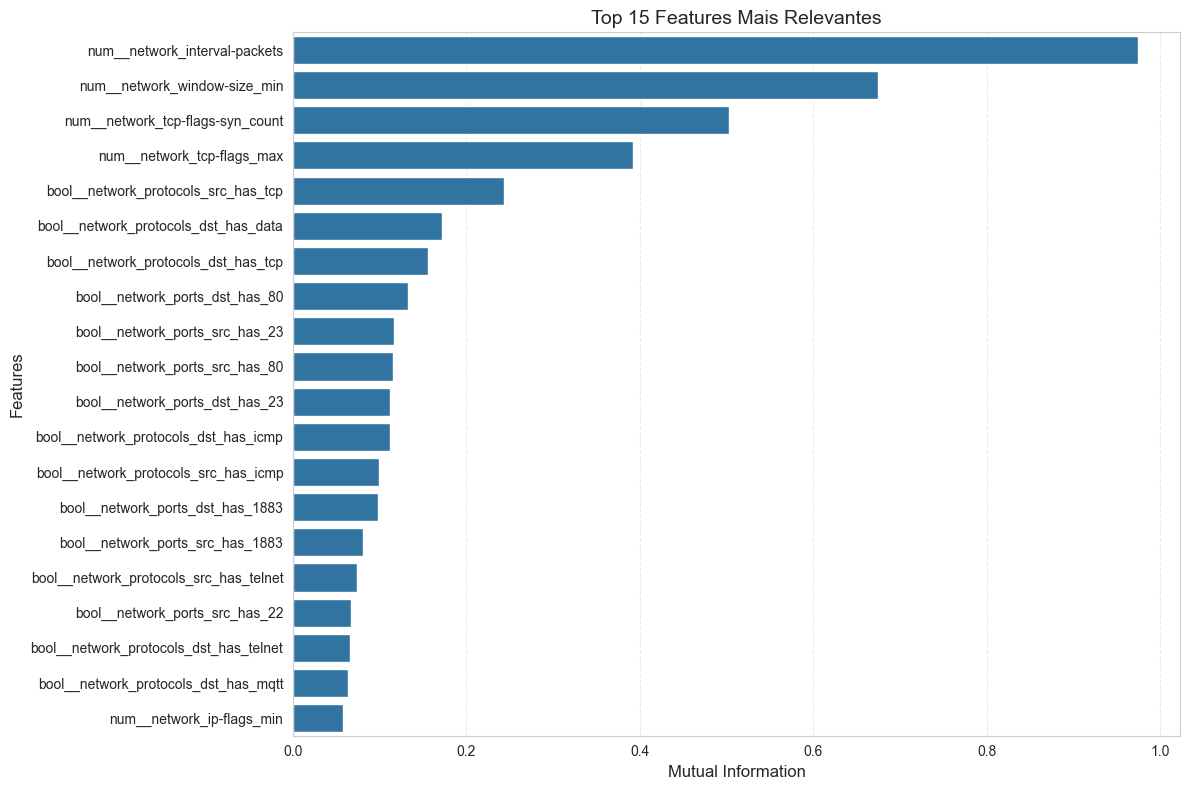

VISUALIZAÇÃO DAS FEATURES FINALIZADA


In [64]:

# TOP FEATURES
top_features = feature_importance.head(20)

# FIGURA
plt.figure(figsize=(12,8))


# BARPLOT
sns.barplot(

    data=top_features,

    x="Mutual_Information",

    y="Feature"
)


# TÍTULO
plt.title(

    "Top 15 Features Mais Relevantes",

    fontsize=14
)


# LABELS
plt.xlabel(

    "Mutual Information",

    fontsize=12
)

plt.ylabel(

    "Features",

    fontsize=12
)


# GRID
plt.grid(

    axis="x",

    linestyle="--",

    alpha=0.4
)

# AJUSTE FINAL
plt.tight_layout()


# EXIBE
plt.show()

print("==================================================")
print("VISUALIZAÇÃO DAS FEATURES FINALIZADA")
print("==================================================")

# 11. SAMPLE WEIGHT

In [65]:
"""
Balancea automaticamente as classes.

- class_weight="balanced"
não considera device imbalance

"""

sample_weight = compute_sample_weight(

    class_weight="balanced",

    y=df_train["label_extended"]
)

print("Sample weights calculados.")

Sample weights calculados.


# 12. DEFINIÇÃO DO MODELO BASE

In [66]:

# acelera MUITO o treinamento
model_base = LogisticRegression(

    max_iter=100,

    random_state=42,

    solver="saga",

    penalty="elasticnet",

    l1_ratio=0.5
)

print("Modelo configurado.")

Modelo configurado.


# 13. GRID SEARCH

In [67]:
experimentos = [

    {"suffix": "all", "target": "label4"},

    {"suffix": "binary", "target": "label1"},

    {"suffix": "grouped", "target": "label2"}
]

# LOOP PRINCIPAL
for exp in experimentos:

    print("\n==================================================")
    print(f"TREINANDO CENÁRIO: {exp['suffix']}")
    print("==================================================")

    y_train_exp = df_train[
        exp["target"]
    ]

    y_test_exp = df_test[
        exp["target"]
    ]

    # GRID
    param_grid = {

        "C": [0.1, 1.0], ## "C": [0.1, 1.0, 10],

        "l1_ratio": [0.1, 0.5] ## "l1_ratio": [0.1, 0.5, 0.9]
    }

    grid = GridSearchCV(

        estimator=model_base,

        param_grid=param_grid,

        scoring="f1_macro",

        cv=3, ## 5

        verbose=2,

        n_jobs=4 ## -1
    )

    print("\nIniciando treinamento...")

    grid.fit(

        X_train_selected,

        y_train_exp,

        sample_weight=sample_weight
    )


    # MELHORES PARÂMETROS
    print("\nMelhores parâmetros encontrados:")

    print(grid.best_params_)


TREINANDO CENÁRIO: all

Iniciando treinamento...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Melhores parâmetros encontrados:
{'C': 1.0, 'l1_ratio': 0.1}

TREINANDO CENÁRIO: binary

Iniciando treinamento...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Melhores parâmetros encontrados:
{'C': 1.0, 'l1_ratio': 0.1}

TREINANDO CENÁRIO: grouped

Iniciando treinamento...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Melhores parâmetros encontrados:
{'C': 1.0, 'l1_ratio': 0.1}


In [68]:

# DIRETÓRIO DE RESULTADOS
path_dir = (

    f"results/logistic_regression_full_"

    f"{exp['suffix']}"
)

os.makedirs(

    path_dir,

    exist_ok=True
)

print(f"\nSalvando resultados em: {path_dir}")


# PIPELINE FINAL
best_pipeline = Pipeline([

    ("transformer", preprocessor),

    ("model", grid.best_estimator_)
])


# SALVAR PIPELINE
with open(

    f"{path_dir}/pipe.pickle",

    "wb"
) as f:

    pickle.dump(

        best_pipeline,

        f
    )

print("Pipeline salva.")


# PREDICT PROBA - TREINO
y_prob_train = grid.best_estimator_.predict_proba(

    X_train_selected
)

df_prob_train = pd.DataFrame(

    y_prob_train,

    columns=grid.best_estimator_.classes_
)

df_prob_train.to_parquet(

    f"{path_dir}/train_predict_proba.parquet"
)

print("train_predict_proba salvo.")


# PREDICT PROBA - TESTE
y_prob_test = grid.best_estimator_.predict_proba(

    X_test_selected
)

df_prob_test = pd.DataFrame(

    y_prob_test,

    columns=grid.best_estimator_.classes_
)

df_prob_test.to_parquet(

    f"{path_dir}/test_predict_proba.parquet"
)

print("test_predict_proba salvo.")


# FEATURE IMPORTANCE
coef_importance = np.mean(

    np.abs(

        grid.best_estimator_.coef_

    ),

    axis=0
)

feature_importance = pd.DataFrame({

    "feature": selected_features,

    "importance": coef_importance
})

feature_importance = feature_importance.sort_values(

    by="importance",

    ascending=False
)

feature_importance.to_csv(

    f"{path_dir}/feature_importance.csv",

    index=False
)

print("feature_importance.csv salvo.")

# FINALIZAÇÃO
print("\nCenário finalizado com sucesso.")


Salvando resultados em: results/logistic_regression_full_grouped
Pipeline salva.
train_predict_proba salvo.
test_predict_proba salvo.
feature_importance.csv salvo.

Cenário finalizado com sucesso.


# 14. PREDIÇÃO MULTICLASSE

In [70]:
"""
==================================================
PREDIÇÕES E ANÁLISE DE CONFIANÇA
==================================================

OBJETIVO:
Executar:

- predições
- probabilidades
- análise de confiança
- margem entre classes

Utiliza o melhor modelo encontrado no GridSearch.
"""

# ==================================================
# MELHOR MODELO
# ==================================================

best_model = grid.best_estimator_

# verifica se foi treinado
check_is_fitted(best_model)

print("==================================================")
print("GERANDO PREDIÇÕES")
print("==================================================")

# ==================================================
# PREDIÇÕES
# ==================================================

# USA OS DADOS JÁ PROCESSADOS/SELECIONADOS
y_prob = best_model.predict_proba(
    X_test_selected
)

y_pred = best_model.predict(
    X_test_selected
)

# ==================================================
# CLASSES
# ==================================================

classes = best_model.classes_

# ==================================================
# CONFIANÇA DA PREDIÇÃO
# ==================================================

# maior probabilidade
max_prob = np.max(
    y_prob,
    axis=1
)

# ordena probabilidades
sorted_probs = np.sort(
    y_prob,
    axis=1
)

# segunda maior probabilidade
second_best_prob = sorted_probs[:, -2]

# margem de confiança
confidence_margin = (
    max_prob - second_best_prob
)

# ==================================================
# DATAFRAME FINAL
# ==================================================

df_result = pd.DataFrame({

    "Classe_Real": y_test_exp.values,

    "Classe_Predita": y_pred,

    "Probabilidade_Maxima": max_prob,

    "Segunda_Probabilidade": second_best_prob,

    "Margem_Confianca": confidence_margin
})

# ==================================================
# ACERTO / ERRO
# ==================================================

df_result["Correto"] = (

    df_result["Classe_Real"]

    ==

    df_result["Classe_Predita"]
)

# ==================================================
# RESULTADOS
# ==================================================

print("\nResumo da Predição:")

print("-" * 40)

print(f"Total de amostras: {len(df_result)}")

print(f"Acertos: {df_result['Correto'].sum()}")

print(f"Erros: {(~df_result['Correto']).sum()}")

print("-" * 40)

# ==================================================
# VISUALIZAÇÃO
# ==================================================

display(
    df_result.head()
)

GERANDO PREDIÇÕES

Resumo da Predição:
----------------------------------------
Total de amostras: 56798
Acertos: 14334
Erros: 42464
----------------------------------------


,Classe_Real,Classe_Predita,Probabilidade_Maxima,Segunda_Probabilidade,Margem_Confianca,Correto
0,benign,recon,0.882370,0.079087,0.803284,False
1,benign,recon,0.515329,0.152305,0.363024,False
2,benign,recon,0.515329,0.152305,0.363024,False
3,recon,recon,0.572330,0.206402,0.365928,True
4,benign,recon,0.515329,0.152305,0.363024,False


# 15. AMOSTRAS MAIS CONFIANTES

In [72]:
"""
Identifica e exibir as amostras onde o modelo teve o 
maior grau de certeza (Top 20).
"""

# Ordenação por probabilidade máxima
mais_confiantes = df_result.sort_values(
    by="Probabilidade_Maxima",
    ascending=False
)

print(f"Análise de confiança concluída para o cenário: {exp['suffix']}")
print(f"Shape da matriz de probabilidades: {y_prob.shape} (Amostras, Classes)")

display(mais_confiantes.head(20))

Análise de confiança concluída para o cenário: grouped
Shape da matriz de probabilidades: (56798, 8) (Amostras, Classes)


,Classe_Real,Classe_Predita,Probabilidade_Maxima,Segunda_Probabilidade,Margem_Confianca,Correto
1030,recon,recon,1.000000,1.001327e-13,1.000000,True
603,recon,recon,1.000000,1.001436e-13,1.000000,True
27347,recon,recon,1.000000,1.001024e-13,1.000000,True
21435,recon,recon,1.000000,1.000623e-13,1.000000,True
40147,recon,recon,1.000000,1.003660e-13,1.000000,True
1717,recon,recon,1.000000,2.415482e-12,1.000000,True
51700,recon,recon,1.000000,1.952777e-08,1.000000,True
40243,recon,recon,1.000000,7.101827e-08,1.000000,True
8631,recon,recon,0.999999,9.483831e-07,0.999998,True
8055,recon,recon,0.999999,1.261955e-06,0.999997,True


# 16. AMOSTRAS MAIS INCERTAS

In [73]:
"""
Identifica amostras onde o modelo teve maior dificuldade 
de decisão (menor margem entre as duas melhores classes).
"""

# Ordenação ascendente: menores margens primeiro
mais_incertas = df_result.sort_values(
    by="Margem_Confianca",
    ascending=True
)

print(f"Analisando amostras críticas do cenário: {exp['suffix']}")
print("As amostras abaixo possuem probabilidades muito próximas para classes diferentes.")

display(mais_incertas.head(20))

Analisando amostras críticas do cenário: grouped
As amostras abaixo possuem probabilidades muito próximas para classes diferentes.


,Classe_Real,Classe_Predita,Probabilidade_Maxima,Segunda_Probabilidade,Margem_Confianca,Correto
23558,benign,recon,0.417750,0.417734,0.000016,False
13309,benign,recon,0.282894,0.282870,0.000024,False
43862,benign,recon,0.282894,0.282870,0.000024,False
2617,mitm,recon,0.283148,0.283076,0.000072,False
1574,bruteforce,dos,0.282941,0.282815,0.000127,False
22287,benign,recon,0.282954,0.282817,0.000138,False
7723,malware,dos,0.282951,0.282804,0.000147,False
22563,web,ddos,0.461420,0.461266,0.000155,False
21524,web,ddos,0.461420,0.461266,0.000155,False
3745,web,ddos,0.461420,0.461266,0.000155,False


# 17. MÉTRICAS

In [74]:
"""
============================================================
Avalia o desempenho estatístico do modelo final utilizando
métricas de acurácia, F1-Score e o relatório por classe.
============================================================
"""

# Usamos y_test_exp para garantir que os rótulos batam com o 
# experimento atual (all, binary ou grouped)
print(f"Avaliando métricas para o cenário: {exp['suffix']}\n")

print("Accuracy:")
print(accuracy_score(y_test_exp, y_pred))

print("\nF1 Macro (Média simples entre as classes):")
print(f1_score(y_test_exp, y_pred, average="macro"))

print("\nF1 Weighted (Média ponderada pelo suporte):")
print(f1_score(y_test_exp, y_pred, average="weighted"))

print("\nClassification Report:")
print(
    classification_report(
        y_test_exp, 
        y_pred, 
        zero_division=0
    )
)

Avaliando métricas para o cenário: grouped

Accuracy:
0.25236804112820876

F1 Macro (Média simples entre as classes):
0.37682732276914976

F1 Weighted (Média ponderada pelo suporte):
0.15883078275718332

Classification Report:
              precision    recall  f1-score   support

      benign       0.68      0.00      0.00     34200
  bruteforce       0.91      0.20      0.33       465
        ddos       0.48      0.32      0.39      4501
         dos       0.39      0.60      0.47      4582
     malware       0.89      0.70      0.78      1888
        mitm       0.43      0.19      0.26      2018
       recon       0.18      0.95      0.31      8445
         web       0.50      0.45      0.47       699

    accuracy                           0.25     56798
   macro avg       0.56      0.43      0.38     56798
weighted avg       0.57      0.25      0.16     56798



# 18. TOP-K ACCURACY

In [75]:
"""
Avaliar a probabilidade da classe real estar entre as K 
maiores probabilidades preditas pelo modelo.
"""
# O parâmetro 'labels' garante que a ordem das colunas em y_prob seja respeitada

print(f"Analisando Top-K Accuracy para: {exp['suffix']}")

top1 = top_k_accuracy_score(
    y_test_exp, 
    y_prob, 
    k=1, 
    labels=classes
)

top3 = top_k_accuracy_score(
    y_test_exp, 
    y_prob, 
    k=3, 
    labels=classes
)

top5 = top_k_accuracy_score(
    y_test_exp, 
    y_prob, 
    k=5, 
    labels=classes
)

print("-" * 30)
print(f"Top-1 Accuracy (Igual à acurácia global): {top1:.4f}")
print(f"Top-3 Accuracy:                         {top3:.4f}")
print(f"Top-5 Accuracy:                         {top5:.4f}")
print("-" * 30)

if top5 > 0.80:
    print("Insight: Embora o Top-1 seja desafiador, o modelo coloca a classe correta entre as 5 principais na maioria das vezes.")

Analisando Top-K Accuracy para: grouped
------------------------------
Top-1 Accuracy (Igual à acurácia global): 0.2524
Top-3 Accuracy:                         0.4269
Top-5 Accuracy:                         0.9658
------------------------------
Insight: Embora o Top-1 seja desafiador, o modelo coloca a classe correta entre as 5 principais na maioria das vezes.


# 19. ROC-AUC MULTICLASSE

In [76]:
"""
============================================================
Calcula a área sob a curva ROC utilizando a estratégia 
One-vs-Rest (OvR) para avaliar a separabilidade das classes.
============================================================
"""

print(f"Calculando ROC-AUC para o cenário: {exp['suffix']}")

# Binarização dos rótulos reais para o cálculo multiclasse
# Uso o y_test_exp para manter a consistência com o loop
y_test_bin = label_binarize(y_test_exp, classes=classes)

try:
    roc_auc_macro = roc_auc_score(
        y_test_bin, 
        y_prob, 
        average="macro", 
        multi_class="ovr"
    )

    roc_auc_weighted = roc_auc_score(
        y_test_bin, 
        y_prob, 
        average="weighted", 
        multi_class="ovr"
    )

    print("-" * 30)
    print(f"ROC-AUC Macro:    {roc_auc_macro:.4f}")
    print(f"ROC-AUC Weighted: {roc_auc_weighted:.4f}")
    print("-" * 30)
    
except ValueError as e:
    # Caso ocorra erro por falta de amostras de alguma classe no fold de teste
    print(f"Aviso: Não foi possível calcular o ROC-AUC para algumas classes: {e}")

Calculando ROC-AUC para o cenário: grouped
------------------------------
ROC-AUC Macro:    0.8613
ROC-AUC Weighted: 0.8719
------------------------------


# 20. MATRIZ DE CONFUSÃO

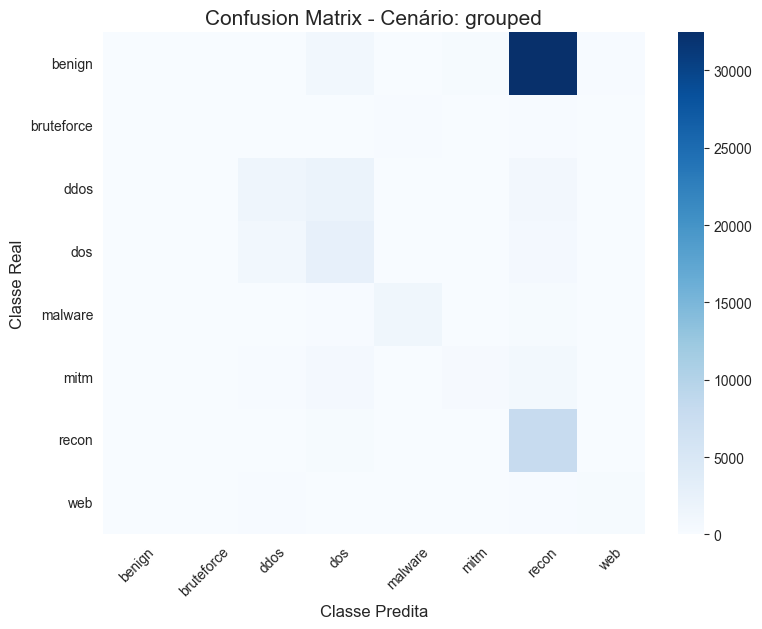

MATRIZ DE CONFUSÃO GERADA

Cenário analisado: grouped

Quantidade de classes: 8

Shape da matriz: (8, 8)


In [78]:
"""
==================================================
MATRIZ DE CONFUSÃO
==================================================

OBJETIVO:
Visualizar:

- acertos
- erros
- distribuição das predições
- comportamento do modelo por classe

A matriz de confusão mostra:

LINHAS   -> classe real
COLUNAS -> classe predita

OBS:
Com muitas classes (84), exibir números em cada célula
torna a visualização poluída.
"""

# MATRIZ DE CONFUSÃO
cm = confusion_matrix(

    y_test_exp,

    y_pred,

    labels=classes
)

# TAMANHO DINÂMICO DA FIGURA
size = 15 if exp['suffix'] == "all" else 8

plt.figure(

    figsize=(size, size * 0.8)
)

# HEATMAP
sns.heatmap(

    cm,

    cmap="Blues",

    annot=False,

    fmt="d"
)


# TÍTULO E EIXOS
plt.title(

    f"Confusion Matrix - Cenário: {exp['suffix']}",

    fontsize=15
)

plt.xlabel(

    "Classe Predita",

    fontsize=12
)

plt.ylabel(

    "Classe Real",

    fontsize=12
)

# EXIBE NOMES DAS CLASSES
if exp['suffix'] != "all":

    plt.xticks(

        np.arange(len(classes)) + 0.5,

        classes,

        rotation=45
    )

    plt.yticks(

        np.arange(len(classes)) + 0.5,

        classes,

        rotation=0
    )

# AJUSTE FINAL
plt.tight_layout()

plt.show()

# RESULTADO
print("==================================================")
print("MATRIZ DE CONFUSÃO GERADA")
print("==================================================")

print(f"\nCenário analisado: {exp['suffix']}")

print(f"\nQuantidade de classes: {len(classes)}")

print(f"\nShape da matriz: {cm.shape}")

# 21. CLASSES MAIS CONFUNDIDAS

In [79]:
"""
==================================================
CLASSES MAIS CONFUNDIDAS
==================================================

OBJETIVO:
Identificar os pares de classes que geram
o maior volume de erros.

Isso ajuda a detectar:

- sobreposição entre ataques
- classes difíceis
- limitações do modelo
"""

# ==================================================
# LISTA DE CONFUSÕES
# ==================================================

confusions = []

print("==================================================")
print(f"ANALISANDO CONFUSÕES - {exp['suffix']}")
print("==================================================")

# ==================================================
# LOOP DA MATRIZ
# ==================================================

for i in range(len(classes)):

    for j in range(len(classes)):

        # ignora acertos
        if i != j:

            # registra apenas erros
            if cm[i, j] > 0:

                confusions.append({

                    "Classe_Real": classes[i],

                    "Classe_Predita": classes[j],

                    "Quantidade": cm[i, j]
                })

# ==================================================
# DATAFRAME
# ==================================================

conf_df = pd.DataFrame(confusions)

# ==================================================
# ORDENAÇÃO
# ==================================================

conf_df = conf_df.sort_values(

    by="Quantidade",

    ascending=False

).reset_index(drop=True)

# ==================================================
# PERCENTUAL DE ERRO
# ==================================================

conf_df["Percentual"] = (

    conf_df["Quantidade"]

    /

    conf_df["Quantidade"].sum()

) * 100

# ==================================================
# RESULTADOS
# ==================================================

print("\nTotal de pares confundidos:")
print(len(conf_df))

print("\nTop 20 maiores confusões:")

display(
    conf_df.head(20)
)

# ==================================================
# INSIGHT AUTOMÁTICO
# ==================================================

if not conf_df.empty:

    maior_erro = conf_df.iloc[0]

    print("\n==================================================")
    print("INSIGHT PRINCIPAL")
    print("==================================================")

    print(

        f"\nO modelo confundiu mais frequentemente:\n"

        f"\nClasse Real: {maior_erro['Classe_Real']}"

        f"\nClasse Predita: {maior_erro['Classe_Predita']}"

        f"\nQuantidade: {maior_erro['Quantidade']}"

        f"\nPercentual: {maior_erro['Percentual']:.2f}%"
    )

ANALISANDO CONFUSÕES - grouped

Total de pares confundidos:
43

Top 20 maiores confusões:


,Classe_Real,Classe_Predita,Quantidade,Percentual
0,benign,recon,32462,76.445931
1,ddos,dos,1985,4.674548
2,dos,ddos,1062,2.500942
3,benign,dos,1031,2.427939
4,ddos,recon,1013,2.385550
5,mitm,recon,810,1.907498
6,dos,recon,718,1.690844
7,mitm,dos,647,1.523644
8,benign,mitm,370,0.871326
9,recon,dos,301,0.708836



INSIGHT PRINCIPAL

O modelo confundiu mais frequentemente:

Classe Real: benign
Classe Predita: recon
Quantidade: 32462
Percentual: 76.45%


# 22. PCA

In [ ]:
"""
============================================================
PCA — VISUALIZAÇÃO DAS CLASSES
============================================================

OBJETIVO:
Reduzir as features para 2 dimensões principais
utilizando PCA.

Isso permite visualizar:

- separação entre classes
- sobreposição
- clusters
- dificuldade de classificação

Utiliza apenas as Top 10 classes
para evitar poluição visual.
============================================================
"""

print("==================================================")
print(f"EXECUTANDO PCA — CENÁRIO: {exp['suffix']}")
print("==================================================")

# ==================================================
# PCA
# ==================================================

pca = PCA(

    n_components=2,

    random_state=42
)

# ==================================================
# REDUÇÃO DE DIMENSIONALIDADE
# ==================================================

X_pca = pca.fit_transform(
    X_test_selected
)

# ==================================================
# DATAFRAME PARA VISUALIZAÇÃO
# ==================================================

df_pca = pd.DataFrame({

    "PCA1": X_pca[:, 0],

    "PCA2": X_pca[:, 1],

    "Classe": y_test_exp.values
})

# ==================================================
# TOP 10 CLASSES MAIS FREQUENTES
# ==================================================

top_classes = y_test_exp.value_counts().head(10).index

df_plot = df_pca[
    df_pca["Classe"].isin(top_classes)
]

# ==================================================
# VISUALIZAÇÃO
# ==================================================

plt.figure(figsize=(12, 8))

sns.scatterplot(

    data=df_plot,

    x="PCA1",

    y="PCA2",

    hue="Classe",

    alpha=0.6
)

# ==================================================
# TÍTULO
# ==================================================

plt.title(

    f"PCA — Top 10 Classes ({exp['suffix']})",

    fontsize=14
)

# ==================================================
# GRID
# ==================================================

plt.grid(

    linestyle="--",

    alpha=0.4
)

# ==================================================
# LEGENDA
# ==================================================

plt.legend(

    bbox_to_anchor=(1.02, 1),

    loc="upper left"
)

# ==================================================
# AJUSTE FINAL
# ==================================================

plt.tight_layout()

plt.show()

# ==================================================
# VARIÂNCIA EXPLICADA
# ==================================================

print("\nVariância explicada pelo PCA:")

print(
    pca.explained_variance_ratio_
)

print("\nVariância acumulada:")

print(
    pca.explained_variance_ratio_.sum()
)

print("\nVisualização PCA concluída.")

Executando PCA para o cenário: grouped...


AttributeError: 'LogisticRegression' object has no attribute 'named_steps'

# 23. t-SNE

Iniciando t-SNE para o cenário: grouped...


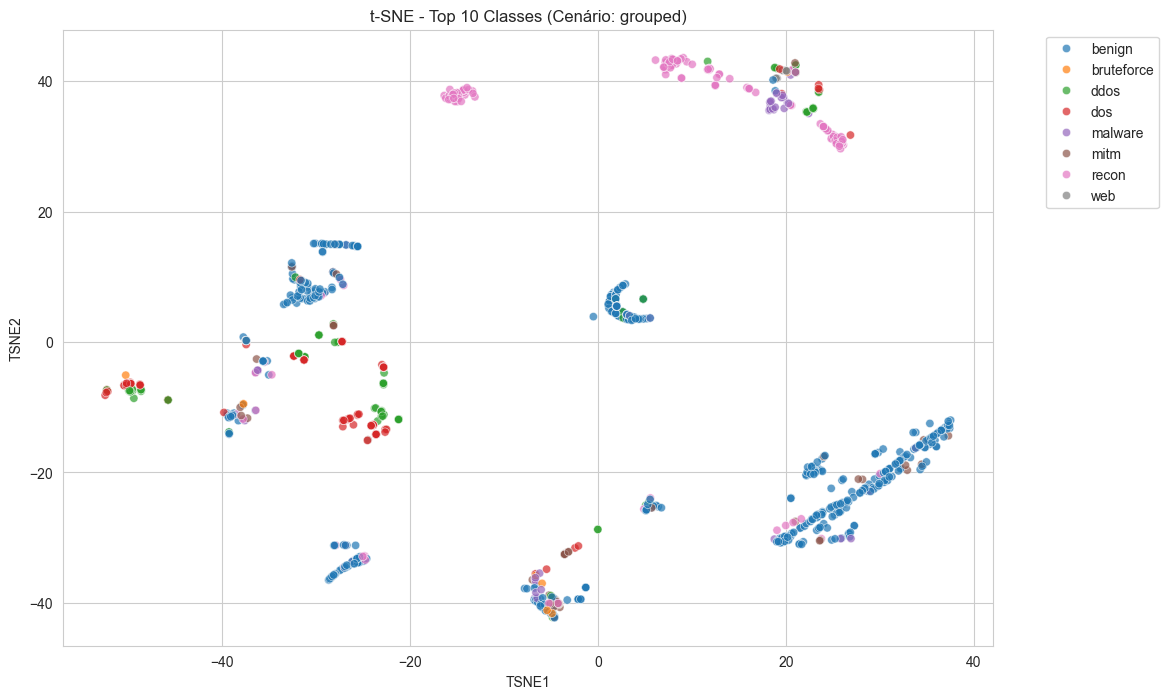

Visualização t-SNE concluída.


In [ ]:
print(f"Iniciando t-SNE para o cenário: {exp['suffix']}...")

sample_size = 1500

# 1. Transformar os dados brutos usando o transformer da Pipeline
X_test_transformed = best_model.named_steps['transformer'].transform(X_test)

# 2. Extrair amostra dos dados já transformados
X_tsne_sample = X_test_transformed[:sample_size]
y_tsne_sample = y_test_exp.iloc[:sample_size]

# 3. Rodar t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_tsne_sample)

df_tsne = pd.DataFrame({
    "TSNE1": X_tsne[:,0],
    "TSNE2": X_tsne[:,1],
    "Classe": y_tsne_sample.values
})

# Plotagem das Top 10
top_classes = y_test_exp.value_counts().head(10).index
df_plot = df_tsne[df_tsne["Classe"].isin(top_classes)]

plt.figure(figsize=(12,8))
sns.scatterplot(data=df_plot, x="TSNE1", y="TSNE2", hue="Classe", alpha=0.7, palette="tab10")
plt.title(f"t-SNE - Top 10 Classes (Cenário: {exp['suffix']})")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print("Visualização t-SNE concluída.")

# 24. SHAP VALUES

CALCULANDO SHAP — grouped

Quantidade de amostras: 100

Shape da amostra:
(100, 30)

Recuperando features finais...

Quantidade de features finais:
30

Criando SHAP Explainer...
Calculando SHAP values...
SHAP calculado com sucesso!

Quantidade de classes:
8

TOP FEATURES — SHAP


,Feature,SHAP_Global
0,bool__network_ports_dst_has_1883,0.848590
1,num__network_tcp-flags_max,0.579140
2,bool__network_ports_src_has_1883,0.521478
3,bool__network_protocols_src_has_tcp,0.437885
4,bool__network_ports_src_has_80,0.328809
5,bool__network_protocols_dst_has_tcp,0.306588
6,bool__network_ports_dst_has_80,0.248563
7,num__network_tcp-flags-syn_count,0.239446
8,bool__network_protocols_dst_has_data,0.207202
9,num__network_interval-packets,0.194595


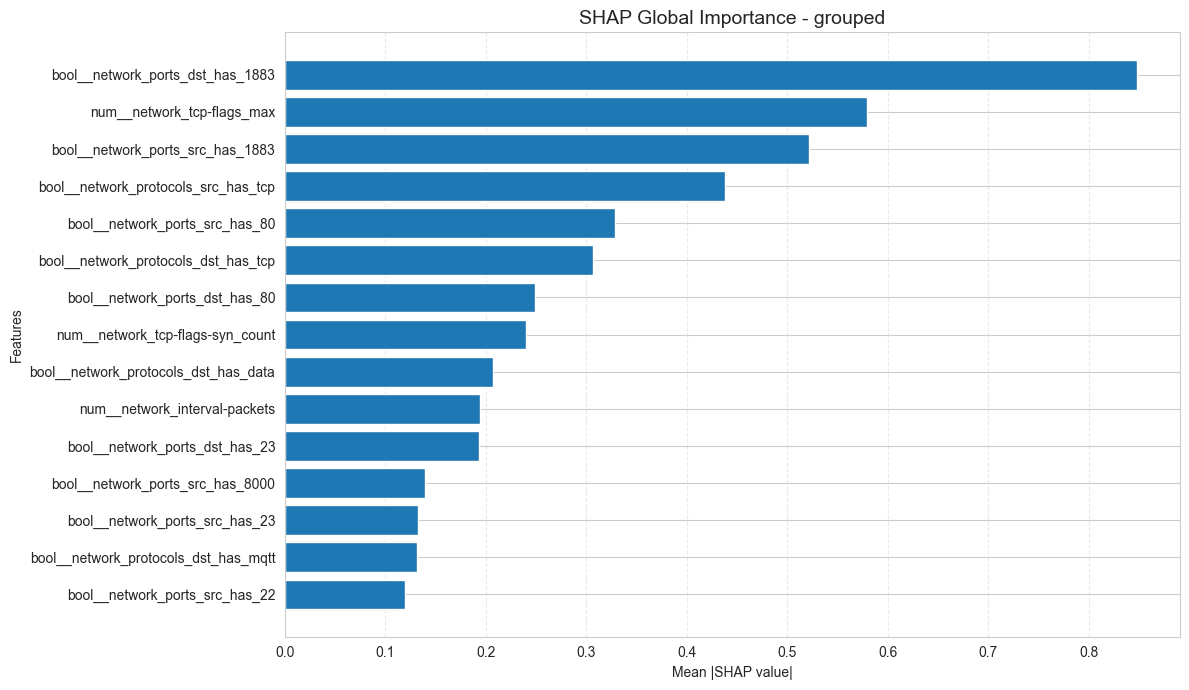


Gerando SHAP Summary Plot...


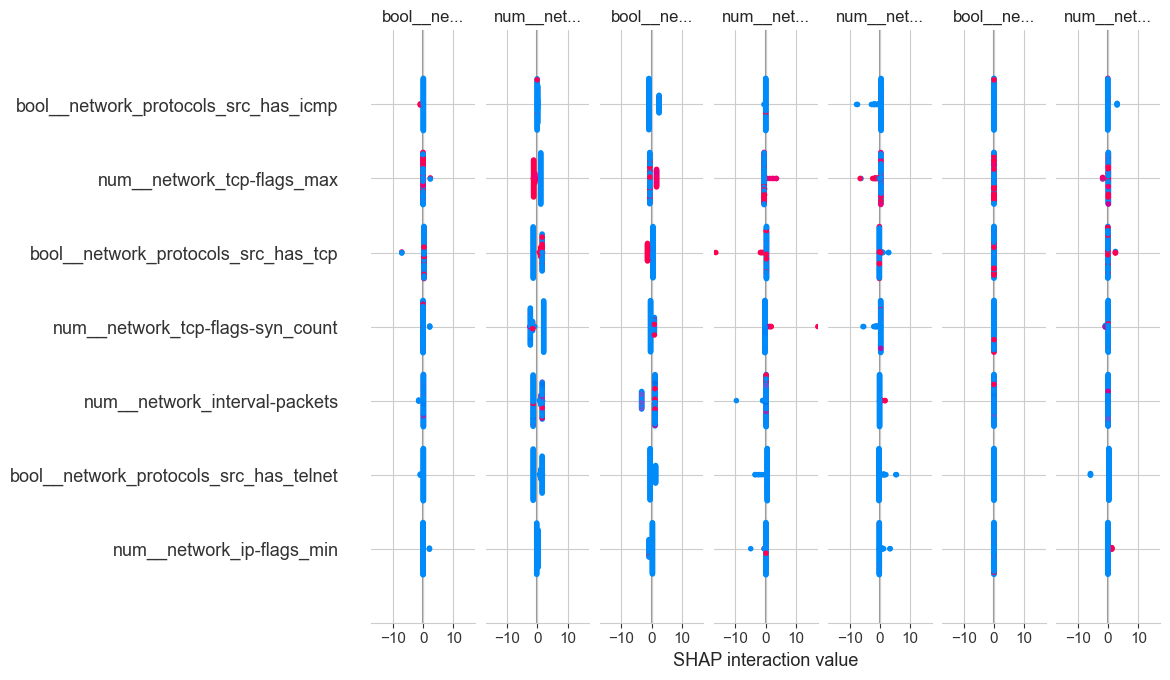


SHAP LOCAL — ANÁLISE DE ERRO

Primeiro erro encontrado: 0


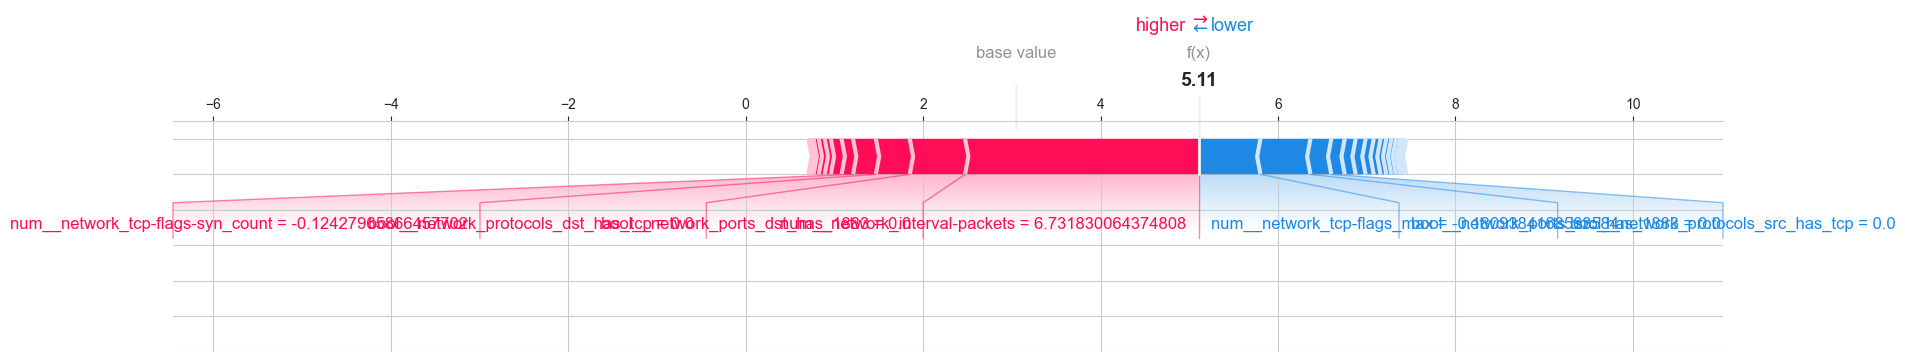


SHAP FINALIZADO


In [82]:
"""
Interpretar o comportamento do modelo treinado
utilizando SHAP (Shapley Additive Explanations).

O SHAP permite identificar:

1. Features mais importantes globalmente
2. Impacto individual das features
3. Motivos dos erros do modelo
4. Features que mais influenciam as decisões

OBSERVAÇÕES IMPORTANTES

shap.Explainer:
- mais moderno
- mais estável
- recomendado nas versões atuais do SHAP

sample_size:
- reduzido para acelerar processamento
- SHAP pode ser extremamente pesado

==================================================
"""

print("==================================================")
print(f"CALCULANDO SHAP — {exp['suffix']}")
print("==================================================")

# ==================================================
# AMOSTRA SHAP
# ==================================================

sample_size = 100

print(f"\nQuantidade de amostras: {sample_size}")

# ==================================================
# AMOSTRA DOS DADOS
# ==================================================

X_sample = X_test_selected[:sample_size]

print("\nShape da amostra:")

print(X_sample.shape)

# ==================================================
# FEATURES FINAIS
# ==================================================

print("\nRecuperando features finais...")

feature_names = preprocessor.get_feature_names_out()

feature_names_variance = feature_names[
    variance_filter.get_support()
]

selected_features = feature_names_variance[
    selector.get_support()
]

print("\nQuantidade de features finais:")

print(len(selected_features))

# ==================================================
# EXPLAINER
# ==================================================

print("\nCriando SHAP Explainer...")

explainer = shap.Explainer(

    best_model,

    X_sample
)

# ==================================================
# SHAP VALUES
# ==================================================

print("Calculando SHAP values...")

shap_values = explainer(X_sample)

print("SHAP calculado com sucesso!")

# ==================================================
# ARRAY SHAP
# ==================================================

shap_array = shap_values.values

# ==================================================
# CLASSES
# ==================================================

class_names = best_model.classes_

print("\nQuantidade de classes:")

print(len(class_names))

# ==================================================
# IMPORTÂNCIA GLOBAL
# ==================================================

global_importance = np.mean(

    np.abs(shap_array),

    axis=(0, 2)
)

# ==================================================
# DATAFRAME GLOBAL
# ==================================================

df_global = pd.DataFrame({

    "Feature": selected_features,

    "SHAP_Global": global_importance
})

df_global = df_global.sort_values(

    by="SHAP_Global",

    ascending=False

).reset_index(drop=True)

# ==================================================
# RESULTADOS
# ==================================================

print("\n==================================================")
print("TOP FEATURES — SHAP")
print("==================================================")

display(
    df_global.head(20)
)

# ==================================================
# VISUALIZAÇÃO GLOBAL
# ==================================================

top_features_shap = df_global.head(15)

plt.figure(figsize=(12, 7))

plt.barh(

    top_features_shap["Feature"][::-1],

    top_features_shap["SHAP_Global"][::-1]
)

plt.title(

    f"SHAP Global Importance - {exp['suffix']}",

    fontsize=14
)

plt.xlabel("Mean |SHAP value|")

plt.ylabel("Features")

plt.grid(

    axis="x",

    linestyle="--",

    alpha=0.4
)

plt.tight_layout()

plt.show()

# ==================================================
# SUMMARY PLOT
# ==================================================

print("\nGerando SHAP Summary Plot...")

try:

    shap.summary_plot(

        shap_array,

        X_sample,

        feature_names=selected_features,

        show=True
    )

except Exception as e:

    print(f"Erro no summary plot: {e}")

# ==================================================
# SHAP LOCAL
# ==================================================

print("\n==================================================")
print("SHAP LOCAL — ANÁLISE DE ERRO")
print("==================================================")

try:

    error_idx = (

        df_result[
            df_result["Correto"] == False
        ].index[0]
    )

    print(f"\nPrimeiro erro encontrado: {error_idx}")

    if error_idx < sample_size:

        pred_class_name = (

            df_result.loc[
                error_idx,
                "Classe_Predita"
            ]
        )

        class_idx = list(class_names).index(
            pred_class_name
        )

        base_value = shap_values.base_values[
            error_idx,
            class_idx
        ]

        shap.force_plot(

            base_value,

            shap_array[
                error_idx
            ][:, class_idx],

            X_sample[error_idx],

            feature_names=selected_features,

            matplotlib=True
        )

    else:

        print("\nErro fora da amostra SHAP.")

        print("Aumente sample_size.")

except Exception as e:

    print("\nErro no Force Plot:")

    print(e)

# ==================================================
# FINALIZAÇÃO
# ==================================================

print("\n==================================================")
print("SHAP FINALIZADO")
print("==================================================")